In [2]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import plot as plt
%matplotlib inline

import missingno as msno
from icecream import ic

In [3]:
filename = r"../../data/raw/term-deposit-marketing-2020.csv"
df = pd.read_csv(filename)

In [4]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no


# finding missing data

<Axes: >

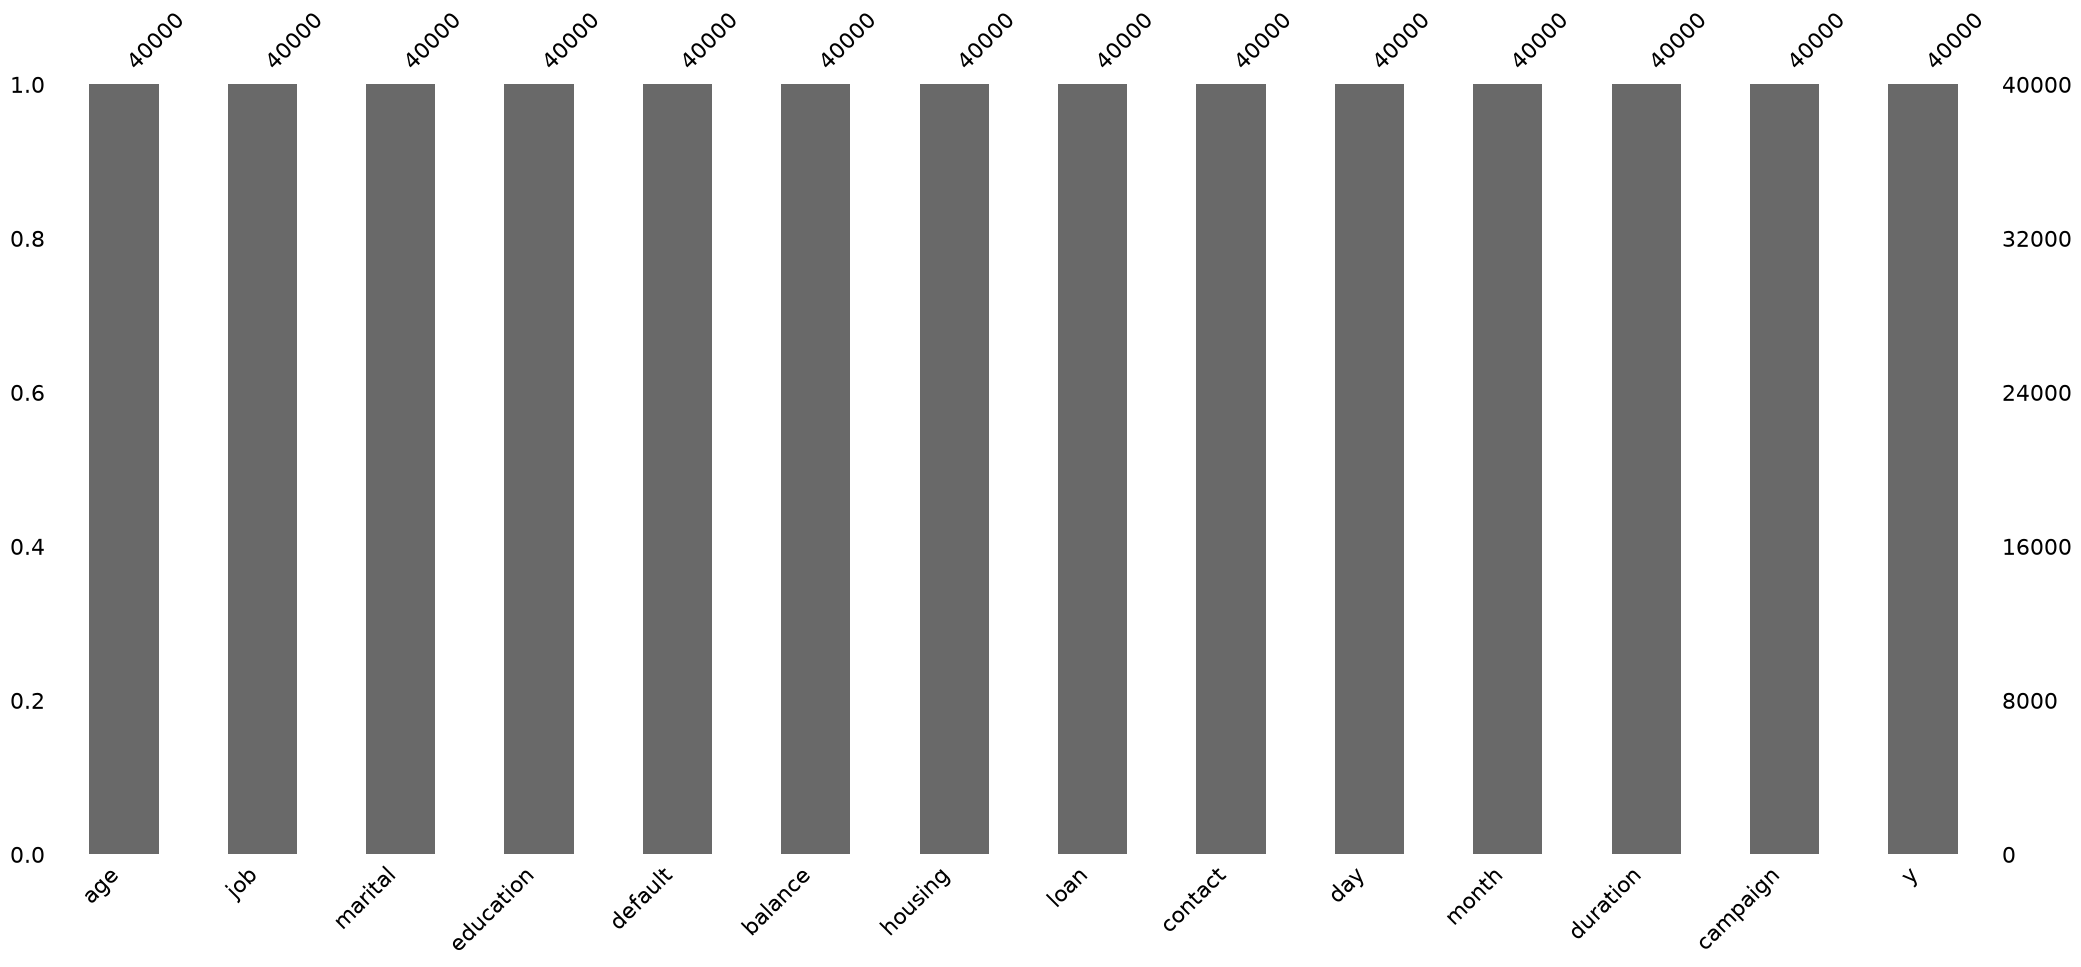

In [7]:
msno.bar(df,)

no empty cells / nan values

___
# Initial thoughts on data available

- no empty cells / NaN / NA
- day and month may be combined without information loss?
- will likely need standardization for certain models affected by eclidian distance
- categorical variables that will need one_hot_encoding = job, marital,
- categorical variables that will need oridinal encoding = education?

### checking dtypes

In [8]:
cat_columns = []
for col in df.columns:
    print(col, ", ", df[col].dtype)
    if df[col].dtype == 'str':
        cat_columns.append(col)

age ,  int64
job ,  str
marital ,  str
education ,  str
default ,  str
balance ,  int64
housing ,  str
loan ,  str
contact ,  str
day ,  int64
month ,  str
duration ,  int64
campaign ,  int64
y ,  str


dtypes are as expected

## Numerical Data Description

In [9]:
df.describe()

,age,balance,day,duration,campaign
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175
std,9.641776,2903.769716,8.278127,259.366498,3.239051
min,19.000000,-8019.000000,1.000000,0.000000,1.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000


## Categorical Data Desciption

In [10]:
for cat in cat_columns:
    ic(cat)
    ic(df[cat].unique())

ic| cat: 'job'
ic| df[cat].unique(): <StringArray>
                      [   'management',    'technician',  'entrepreneur',   'blue-collar',
                             'unknown',       'retired',         'admin',      'services',
                       'self-employed',    'unemployed',     'housemaid',       'student']
                      Length: 12, dtype: str
ic| cat: 'marital'
ic| df[cat].unique(): <StringArray>
                      ['married', 'single', 'divorced']
                      Length: 3, dtype: str
ic| cat: 'education'
ic| df[cat].unique(): <StringArray>
                      ['tertiary', 'secondary', 'unknown', 'primary']
                      Length: 4, dtype: str
ic| cat: 'default'
ic| df[cat].unique(): <StringArray>
                      ['no', 'yes']
                      Length: 2, dtype: str
ic| cat: 'housing'
ic| df[cat].unique(): <StringArray>
                      ['yes', 'no']
                      Length: 2, dtype: str
ic| cat: 'loan'
ic| df[cat].unique(

"unknown" seems to be missing data for the categorical columns

### Checking numerical columns to see if there seems to be blank values in each of the columns

In [11]:
df["campaign"].unique()

array([ 1,  2,  3,  5,  4,  6,  7,  8,  9, 10, 11, 12, 13, 19, 14, 24, 16,
       32, 18, 22, 15, 17, 25, 21, 43, 51, 63, 41, 26, 28, 55, 50, 38, 23,
       20, 29, 31, 37, 30, 46, 27, 58, 33, 35, 34, 36, 39, 44])

In [12]:
for col in filter(lambda x: x not in cat_columns, df.columns):
    ic(col)
    ic(df[col].min())
    ic(np.nan in df[col])
    ic(pd.NA in df[col])
    ic(None in df[col])
    ic(pd.NaT in df[col])



ic| col: 'age'
ic| df[col].min(): np.int64(19)
ic| np.nan in df[col]: False
ic| pd.NA in df[col]: False
ic| None in df[col]: False
ic| pd.NaT in df[col]: False
ic| col: 'balance'
ic| df[col].min(): np.int64(-8019)
ic| np.nan in df[col]: False
ic| pd.NA in df[col]: False
ic| None in df[col]: False
ic| pd.NaT in df[col]: False
ic| col: 'day'
ic| df[col].min(): np.int64(1)
ic| np.nan in df[col]: False
ic| pd.NA in df[col]: False
ic| None in df[col]: False
ic| pd.NaT in df[col]: False
ic| col: 'duration'
ic| df[col].min(): np.int64(0)
ic| np.nan in df[col]: False
ic| pd.NA in df[col]: False
ic| None in df[col]: False
ic| pd.NaT in df[col]: False
ic| col: 'campaign'
ic| df[col].min(): np.int64(1)
ic| np.nan in df[col]: False
ic| pd.NA in df[col]: False
ic| None in df[col]: False
ic| pd.NaT in df[col]: False


### Numerical data seems to be free of unknown data

## Make a processed version where there are no unknown values in the cat_columns

In [13]:
len(df)

40000

In [14]:
no_unknown_df = df.replace("unknown", pd.NA).dropna(inplace=False)

In [15]:
no_unknown_df.education.unique()

<StringArray>
['secondary', 'primary', 'tertiary']
Length: 3, dtype: str

In [16]:
len(no_unknown_df)

26295

In [17]:
processed_filename = r"../../data/processed/no_cat_unknown.csv"
no_unknown_df.to_csv(processed_filename)